# Pregunta de negocio 01/06/2026

**Analista de Perfil i Desempeño Professional:**  
- Quines característiques dels empleats estan associades amb un millor acompliment laboral
- com podem utilitzar aquesta informació per dissenyar estratègies de selecció, capacitació i retenció més efectives?

# Librerías

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from datetime import date
import scipy.stats as stats
import numpy as np

# Documento

In [2]:
df_RRHH = pd.read_csv('../../Data/raw/raw_data_01062026.csv')
df_RRHH

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
0,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
1,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
2,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
3,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112
4,9,12,3,3,2,228,14,16,58,"222,196",...,0,1,2,0,0,1,65,172,22,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840,14,11,11,2,4,155,12,14,34,"284,031",...,0,1,2,1,0,0,95,196,25,120
841,36,13,4,4,3,118,13,18,50,"239,409",...,0,1,1,1,0,0,98,178,31,120
842,9,6,7,3,1,228,14,16,58,"264,604",...,0,1,2,0,0,1,65,172,22,120
843,28,9,7,3,1,225,26,9,28,"230,290",...,0,1,1,0,0,2,69,169,24,112


# Conteo registros

In [3]:
def control_registros(df):

    fecha_actual = date.today()

    total_registros = df.shape[0]
    ID_unicos = df['ID'].nunique()
    ID_extra = total_registros - ID_unicos
    ID_duplicados_exactos = df[df.duplicated(keep=False)].drop_duplicates().shape[0]


    print('--------------------\nCONTROL DE REGISTROS\n--------------------')
    print(f'Fecha: {fecha_actual}\n--------------------')
    print(f'TOTAL REGISTROS: {total_registros}')
    print(f'ID ÚNICOS: {ID_unicos}')
    print(f'ID EXTRAS: {ID_extra}')
    print(f'ID DUPLICADOS EXACTOS: {ID_duplicados_exactos}')

In [4]:
control_registros(df_RRHH) 


--------------------
CONTROL DE REGISTROS
--------------------
Fecha: 2026-06-02
--------------------
TOTAL REGISTROS: 845
ID ÚNICOS: 136
ID EXTRAS: 709
ID DUPLICADOS EXACTOS: 31


# Pregunta de negocio

In [5]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Month_absence', 'Day_week', 'Seasons',
       'Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target', 'Disciplinary_failure',
       'Education', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight',
       'Height', 'Body_mass_index', 'Absenteeism_hours'],
      dtype='str')

In [6]:
df_RRHH.shape

(845, 21)

In [7]:
df_RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,845.0,26.128994,26.374062,1.0,10.0,20.0,33.0,136.0
Reason_absence,845.0,19.280473,8.296957,0.0,13.0,23.0,26.0,28.0
Month_absence,845.0,6.315976,3.457020,0.0,3.0,6.0,9.0,12.0
Day_week,845.0,3.926627,1.417331,2.0,3.0,4.0,5.0,6.0
Seasons,845.0,2.540828,1.111040,1.0,2.0,3.0,4.0,4.0
Transportation_expense,845.0,220.482840,67.416501,118.0,179.0,225.0,260.0,388.0
Distance_Residence_Work,845.0,29.418935,14.740235,5.0,16.0,26.0,49.0,52.0
Service_time,845.0,12.578698,4.424460,1.0,9.0,12.0,16.0,29.0
Age,845.0,36.443787,6.555322,27.0,31.0,37.0,40.0,58.0
Hit_target,845.0,94.572781,3.798349,81.0,93.0,95.0,97.0,100.0


ID


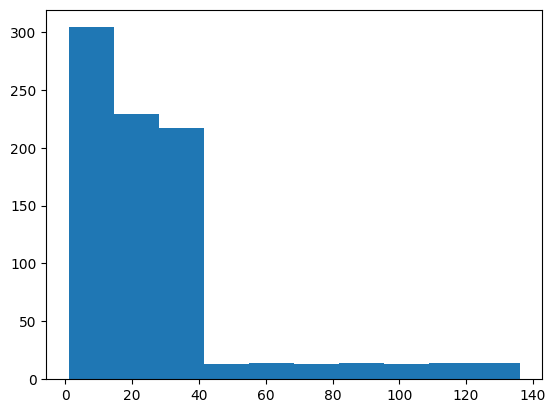

---


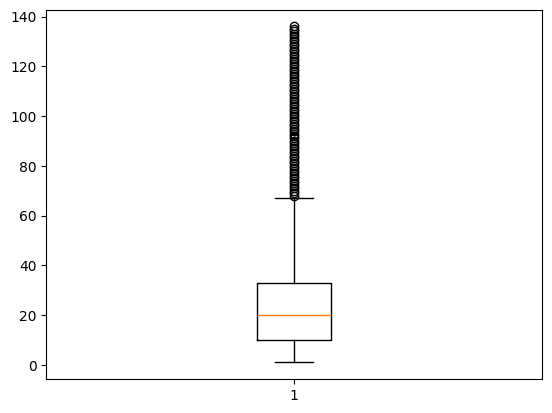

---
Reason_absence


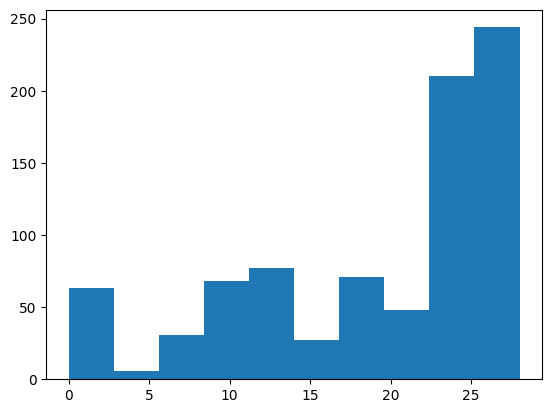

---


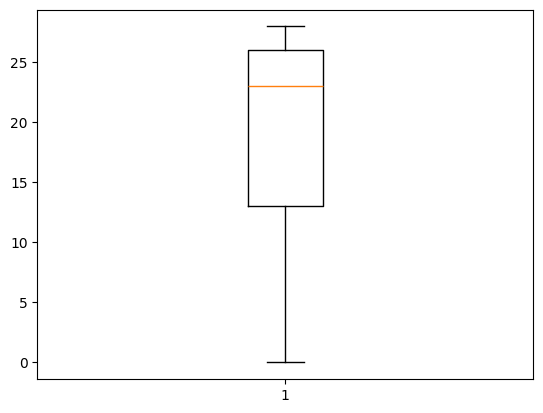

---
Month_absence


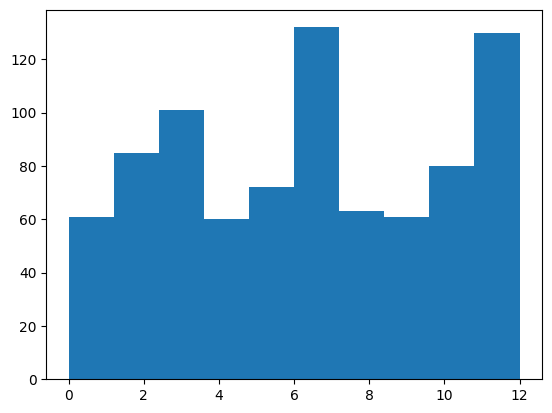

---


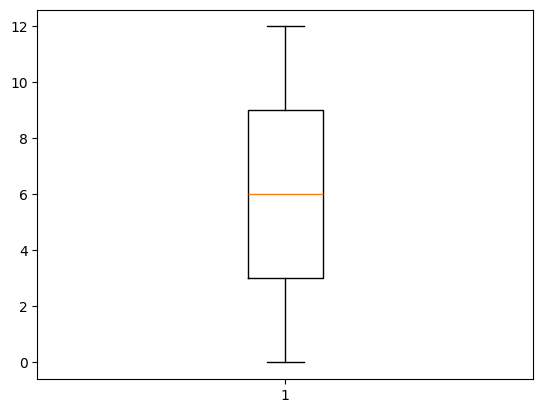

---
Day_week


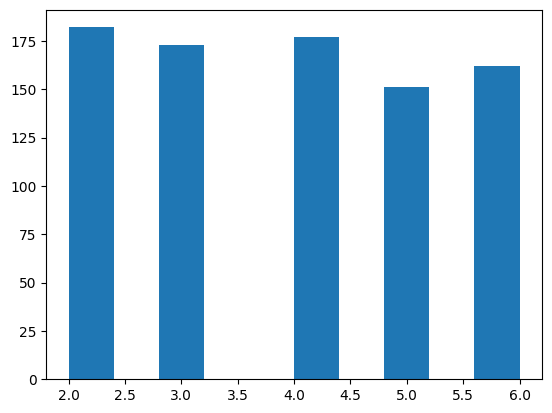

---


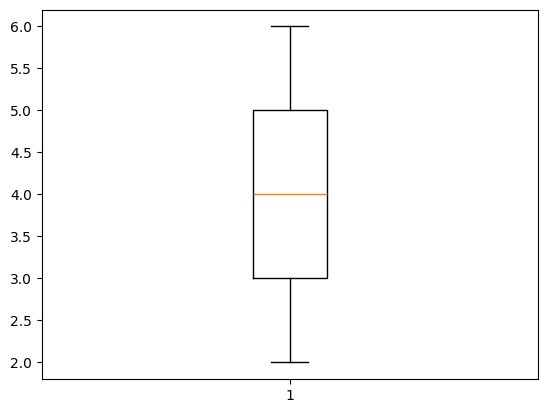

---
Seasons


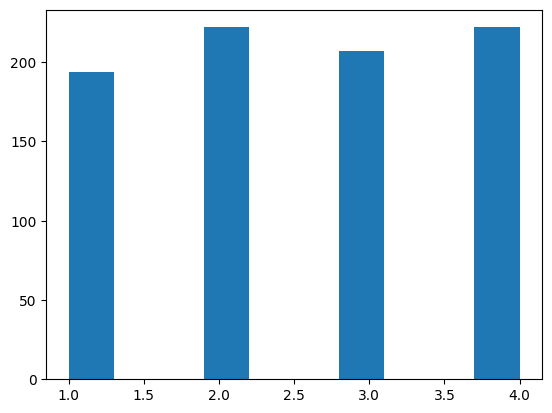

---


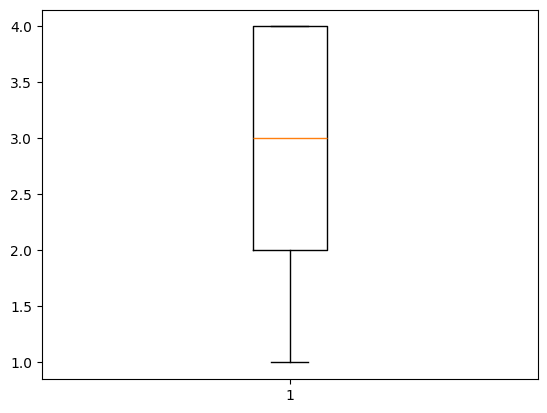

---
Transportation_expense


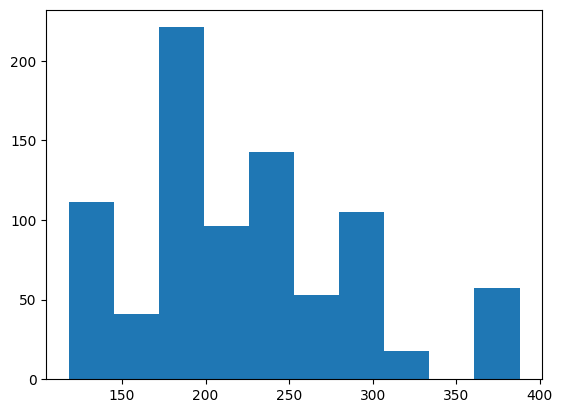

---


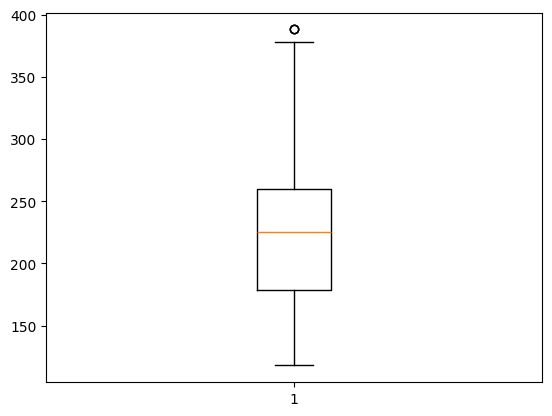

---
Distance_Residence_Work


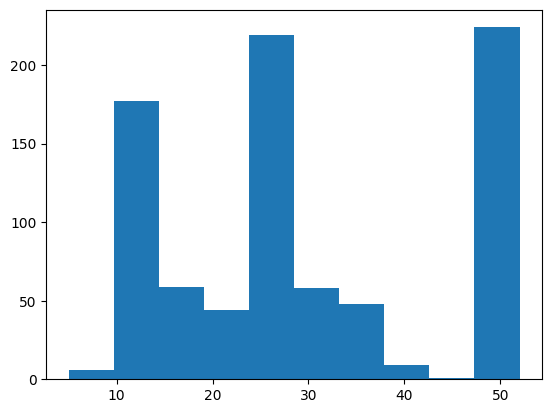

---


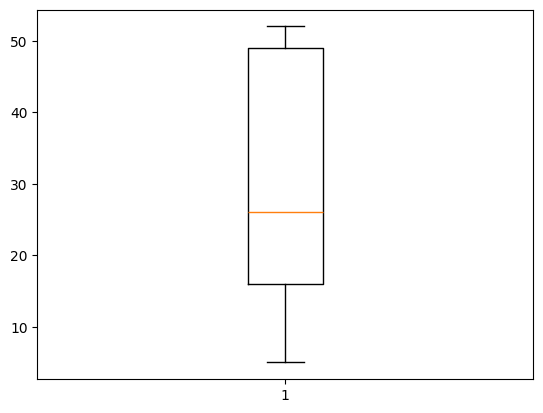

---
Service_time


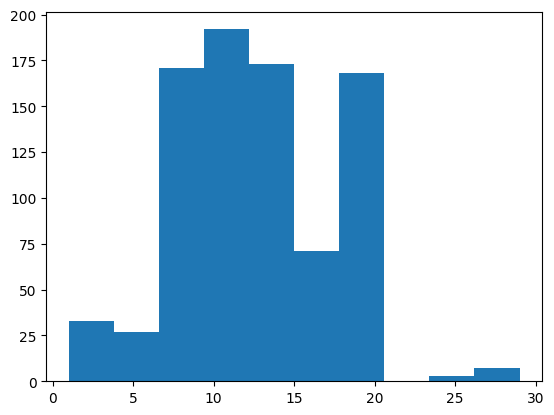

---


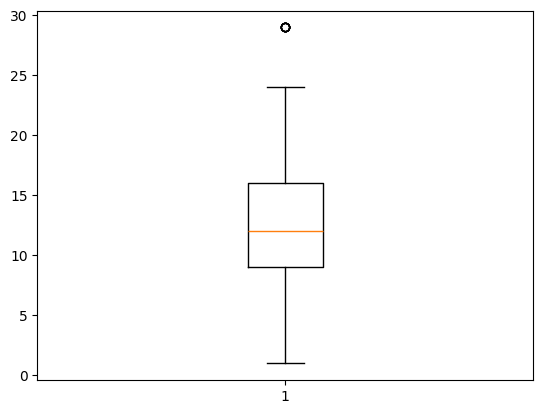

---
Age


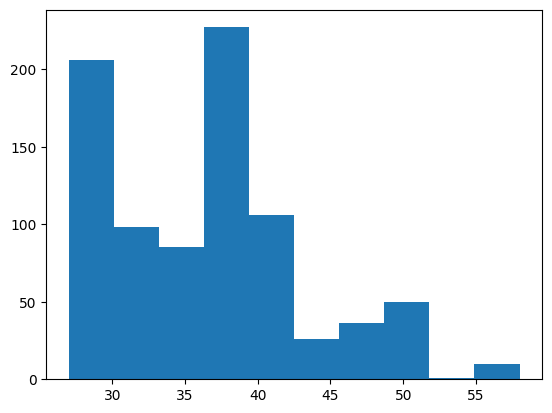

---


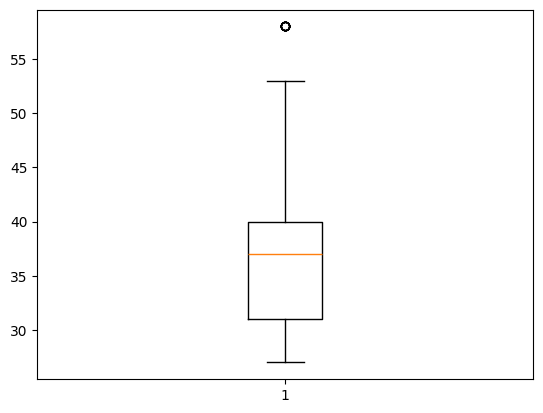

---
Work_load_Average_day


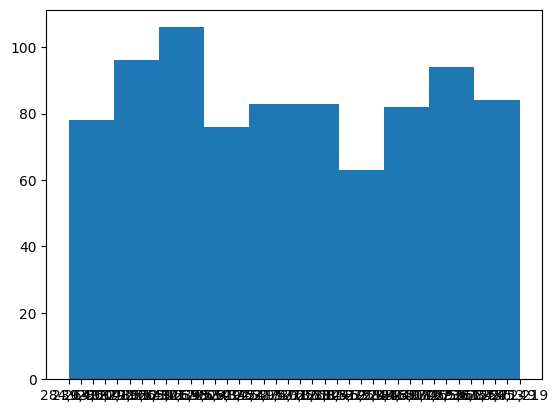

---


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

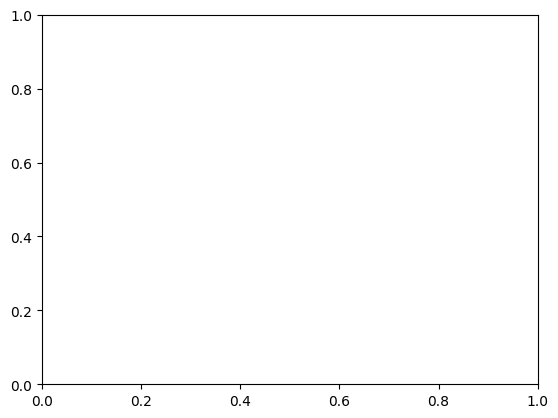

In [24]:
for col in df_RRHH.columns:
    print(col)
    plt.hist(df_RRHH[col])
    plt.show()
    print('---')
    plt.boxplot(df_RRHH[col])
    plt.show()
    # plt.figure(figsize=(6,4))
    # stats.probplot(df_RRHH[col].dropna(), dist="norm", plot=plt)
    # plt.title(f'Q-Q plot de {col}')
    # plt.show()
    print('---')
    

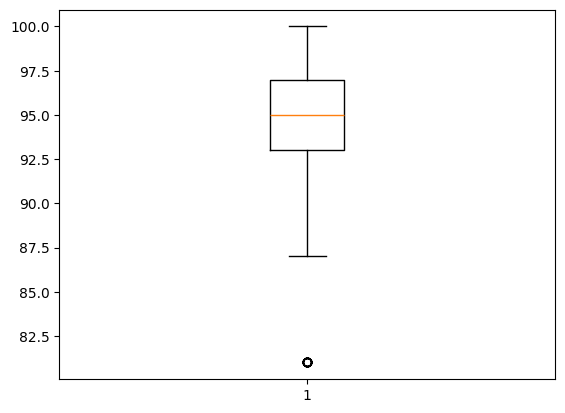

In [25]:
plt.boxplot(df_RRHH['Hit_target'])
plt.show()

# Tamaño de muestra

In [34]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ID                       845 non-null    int64
 1   Reason_absence           845 non-null    int64
 2   Month_absence            845 non-null    int64
 3   Day_week                 845 non-null    int64
 4   Seasons                  845 non-null    int64
 5   Transportation_expense   845 non-null    int64
 6   Distance_Residence_Work  845 non-null    int64
 7   Service_time             845 non-null    int64
 8   Age                      845 non-null    int64
 9   Work_load_Average_day    845 non-null    str  
 10  Hit_target               845 non-null    int64
 11  Disciplinary_failure     845 non-null    int64
 12  Education                845 non-null    int64
 13  Son                      845 non-null    int64
 14  Social_drinker           845 non-null    int64
 15  Social_smoker    

In [35]:
# Función para calcular la moda de variables categóricas/temporales
def moda(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

df_emp = df_RRHH.groupby('ID').agg(
    # Variable dependiente agregada a nivel empleado
    Hit_target_median=('Hit_target', 'median'),
    Hit_target_mean=('Hit_target', 'mean'),

    # Número de solicitudes / registros de ausencia por empleado
    num_absences=('ID', 'size'),

    # Variables numéricas del empleado
    Age=('Age', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),

    # Variables que pueden variar por registro
    Absenteeism_hours_total=('Absenteeism_hours', 'sum'),
    Absenteeism_hours_median=('Absenteeism_hours', 'median'),
    # Work_load_Average_day_median=('Work_load_Average_day', 'median'),

    # Variables categóricas/dummy del empleado
    Disciplinary_failure=('Disciplinary_failure', 'first'),
    Education=('Education', 'first'),
    Son=('Son', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    Pet=('Pet', 'first'),

    # Variables temporales: valor más frecuente por empleado
    Month_absence_mode=('Month_absence', moda),
    Seasons_mode=('Seasons', moda)
).reset_index()

In [36]:
variables_grupo = [
    'Disciplinary_failure',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet'
]

for var in variables_grupo:
    #print(f"\n{var}")
    print(df_emp[var].value_counts(dropna=False))
    print(df_emp[var].value_counts(normalize=True, dropna=False) * 100)

Disciplinary_failure
0    135
1      1
Name: count, dtype: int64
Disciplinary_failure
0    99.264706
1     0.735294
Name: proportion, dtype: float64
Education
1    114
3     12
2      9
4      1
Name: count, dtype: int64
Education
1    83.823529
3     8.823529
2     6.617647
4     0.735294
Name: proportion, dtype: float64
Son
0    59
1    41
2    28
3     5
4     3
Name: count, dtype: int64
Son
0    43.382353
1    30.147059
2    20.588235
3     3.676471
4     2.205882
Name: proportion, dtype: float64
Social_drinker
1    71
0    65
Name: count, dtype: int64
Social_drinker
1    52.205882
0    47.794118
Name: proportion, dtype: float64
Social_smoker
0    122
1     14
Name: count, dtype: int64
Social_smoker
0    89.705882
1    10.294118
Name: proportion, dtype: float64
Pet
0    83
1    24
2    21
4     5
8     2
5     1
Name: count, dtype: int64
Pet
0    61.029412
1    17.647059
2    15.441176
4     3.676471
8     1.470588
5     0.735294
Name: proportion, dtype: float64


# Workload and hit target is by month

hay algún mes que tenga distintos work_load para la misma persona? Sí, por ejemplo individuo 1, pero pueden ser distintos años

In [10]:
# Ver cuántos work_load distintos tiene cada persona en cada mes
workload_check = (
    df_RRHH.groupby(['ID', 'Month_absence'])['Work_load_Average_day']
      .nunique()
      .reset_index(name='n_workloads_distintos')
)

# Filtrar solo los casos donde hay más de un work_load distinto
workload_diferente = workload_check[
    workload_check['n_workloads_distintos'] > 1
]

workload_diferente

,ID,Month_absence,n_workloads_distintos
2,1,4,2
3,1,5,2
4,1,6,2
5,1,7,2
6,1,8,3
...,...,...,...
232,36,6,3
233,36,7,3
235,36,9,2
236,36,10,2


In [11]:
# Obtener combinaciones ID-mes problemáticas
casos = workload_diferente[['ID', 'Month_absence']]

# Filtrar el dataframe original
df_workload_diferente = df_RRHH.merge(
    casos,
    on=['ID', 'Month_absence'],
    how='inner'
).sort_values(['ID', 'Month_absence', 'Work_load_Average_day'])

df_workload_diferente

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
182,1,22,4,6,3,235,11,14,37,"246,288",...,0,3,1,0,0,1,88,172,29,8
278,1,7,4,6,3,235,11,14,37,"326,452",...,0,3,1,0,0,1,88,172,29,3
185,1,22,5,2,3,235,11,14,37,"237,656",...,0,3,1,0,0,1,88,172,29,8
147,1,1,5,2,3,235,11,14,37,"246,074",...,0,3,1,0,0,1,88,172,29,8
149,1,13,6,3,1,235,11,14,37,"253,957",...,0,3,1,0,0,1,88,172,29,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,36,28,10,5,4,118,13,18,50,"265,017",...,0,1,1,1,0,0,98,178,31,1
504,36,23,10,5,4,118,13,18,50,"265,017",...,0,1,1,1,0,0,98,178,31,1
549,36,0,10,6,4,118,13,18,50,"265,017",...,1,1,1,1,0,0,98,178,31,0
509,36,28,12,3,4,118,13,18,50,"236,629",...,0,1,1,1,0,0,98,178,31,1


In [12]:
df_RRHH[df_RRHH['ID'] == 1].sort_values(by='Month_absence')

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_hours
664,1,13,1,3,2,235,11,14,37,"330,061",...,0,3,1,0,0,1,88,172,29,1
725,1,0,3,5,3,235,11,14,37,"244,387",...,1,3,1,0,0,1,88,172,29,0
178,1,22,3,2,2,235,11,14,37,"244,387",...,0,3,1,0,0,1,88,172,29,8
182,1,21,3,5,2,235,11,14,37,"244,387",...,0,3,1,0,0,1,88,172,29,8
364,1,7,4,6,3,235,11,14,37,"326,452",...,0,3,1,0,0,1,88,172,29,3
247,1,22,4,6,3,235,11,14,37,"246,288",...,0,3,1,0,0,1,88,172,29,8
250,1,22,5,2,3,235,11,14,37,"237,656",...,0,3,1,0,0,1,88,172,29,8
193,1,1,5,2,3,235,11,14,37,"246,074",...,0,3,1,0,0,1,88,172,29,8
50,1,13,6,6,3,235,11,14,37,"377,550",...,0,3,1,0,0,1,88,172,29,16
196,1,13,6,3,1,235,11,14,37,"253,957",...,0,3,1,0,0,1,88,172,29,8


- How many work_load and hit target pairs are for each ID and month. For Dataset goes from july 2007 to july 2010, so we have 3 years for most of the months and 4 for july. In our dataset, maximum of pairs is 4 and they correspond to July.

In [19]:
summary = (
    df_RRHH[['ID', 'Month_absence','Work_load_Average_day', 'Hit_target']]
      .drop_duplicates()
      .groupby(['ID','Month_absence'])
      .size()
      .reset_index(name='n_pairs')
      .sort_values('n_pairs', ascending=False)
)

summary.sort_values(by=['ID','Month_absence'])

,ID,Month_absence,n_pairs
0,1,1,1
1,1,3,1
2,1,4,2
3,1,5,2
4,1,6,2
...,...,...,...
333,132,3,1
334,133,9,1
335,134,11,1
336,135,5,1


In [20]:
summary['n_pairs'].unique()

array([4, 3, 2, 1])

In [21]:
summary[summary['n_pairs'] == 4]

,ID,Month_absence,n_pairs
67,11,7,4
56,10,7,4
